In [3]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [37]:
from Visualization import generalVisualization
from Visualization import gloveVisuals
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Utilities import config
from Utilities import reader

import pickle
import select_landmarks_MI
import importlib
import voltagemap
import setofpoints
import main
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import fetch_openml

ERROR! Session/line number was not unique in database. History logging moved to new session 66


In [52]:
importlib.reload(reader)
importlib.reload(mnistVisuals)

<module 'Visualization.mnistVisuals' from '/home/avighna/Documents/python/VoltageDimentionalReduction/clean_code/Visualization/mnistVisuals.py'>

In [18]:
config.params['file_path']= '../../Voltage_Data/glove/glove.6B.300d.txt'
config.params['split_char']= ' '
config.params['normalize_vecs'] = True

config.params['max_centroids']= 1000
config.params['init_size']= 5000
config.params['batch_size']= 1000
config.params['kmeans_output']= '../../Voltage_Temp/Results/glove.npy'
config.params['save_data'] = '../../Voltage_Temp/Results/glove_save_data.pkl'
config.params['k']=10
config.params['r']=1
config.params['alpha']=0.1
config.params['equalize_centroids']=False
config.params['NoOfLandmarks']=10
config.params['DepthOfLandmarkSearch']=100

In [54]:
data_to_save = main.main()

Read 5000 vectors
Estimated max pairwise distance squared, FAISS) = 2.5693
 Estimated minimum distance squared = 0.0000
10 vectors in index after adding initial centroid
Read 6000 vectors
number of centroids: 607, max_centroids: 1000
Read 7000 vectors
number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000
Read 8000 vectors
refining vectors
sorted_sizes=[8 8 7 7 6]
too_small=453, rms=0.042786479991450674, finished=True
Read 9000 vectors
refining vectors
sorted_sizes=[9 8 7 7 7]
too_small=462, rms=0.04203881924307631, finished=True
Read 10000 vectors
refining vectors
sorted_sizes=[17  9  9  8  8]
too_small=483, rms=0.040334224760344234, finished=True
Read 11000 vectors
refining vectors
sorted_sizes=[12 10 10  9  8]
too_small=520, rms=0.03826831267692828, finished=True
Read 12000 vectors
refining vectors
sorted_sizes=[11 11  9  8  7]
too_small=539, rms=0.0370404910339394, finished=True
Read 13000 vectors
refining vectors
sorted_sizes=[9 9 8 8 8]
too_small

In [55]:
data_to_save['voltage_map'] = select_landmarks_MI.select_landmarks(data_to_save['all_voltages'])

Starting landmark selection based on mutual information took 0.00 seconds
calculated MI for each singleton took 185.97 seconds
Adding landmark index=0 lm_index=30 with MI=0.4368
Adding landmark index=1 lm_index=139 with MI=0.8381
Adding landmark index=5 lm_index=234 with MI=1.1777
Adding landmark index=5 lm_index=795 with MI=1.5849
Adding landmark index=9 lm_index=210 with MI=1.9198
Adding landmark index=22 lm_index=184 with MI=2.1872
Adding landmark index=14 lm_index=346 with MI=2.6126
Adding landmark index=7 lm_index=446 with MI=2.9043
Adding landmark index=12 lm_index=255 with MI=3.1451
Adding landmark index=27 lm_index=581 with MI=3.3735
Selected 10 landmarks based on mutual information took 203.65 seconds


In [56]:
with open(config.params['save_data'], 'wb') as f:
    pickle.dump(data_to_save, f)

In [57]:
with open(config.params['save_data'], 'rb') as f:
    data_to_save = pickle.load(f)

In [58]:
voltages = data_to_save['voltage_map']
centroids = data_to_save['centroids']
label_counts = data_to_save['label_counts']
points = voltages.voltage_array()
transformed_points = visualHelpers.transform(points, 'pca')

Number of point_voltages with no label: 760
Plot saved to mnist_visualization.png


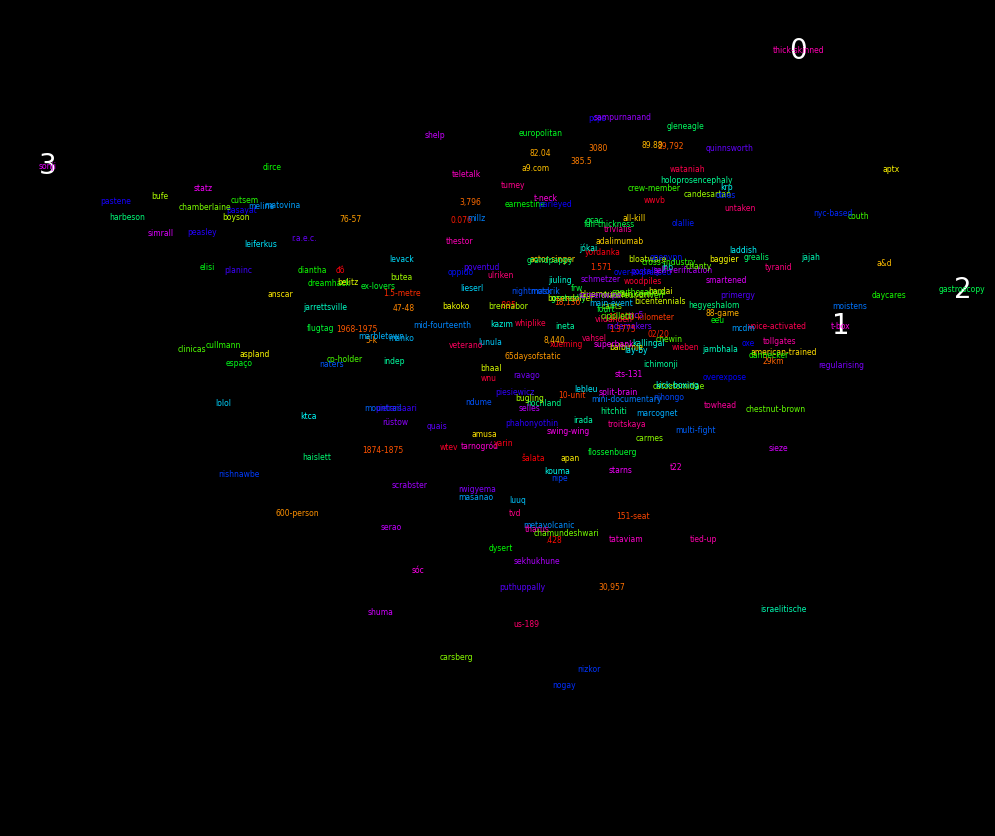

In [60]:
focus_on = np.array([0,1,2,3,4,5,6,7,8,9])
mnistVisuals.plot_landmark_subset(points, centroids, label_counts, focus_on, alpha_actual=1, element='label', size_threshold=0, ratio_threshold=0)

Number of point_voltages with no label: 235
Plot saved to mnist_visualization.png


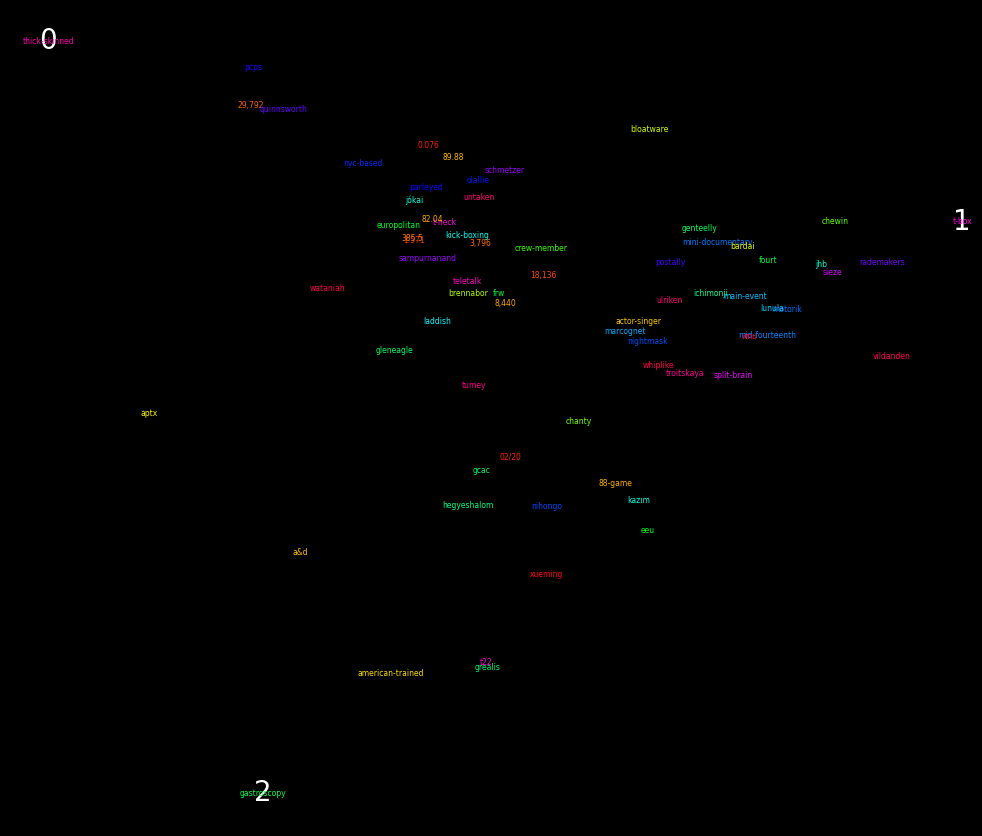

In [64]:
focus_on = np.array([0,1,2])
mnistVisuals.plot_landmark_subset(points, centroids, label_counts, focus_on, alpha_actual=1, element='label', size_threshold=0, ratio_threshold=0)

Read 1000 vectors<class 'voltagemap.VoltageMap'>
Number of landmarks: 10
Number of point_voltages with no label: 0
Plot saved to mnist_visualization.png


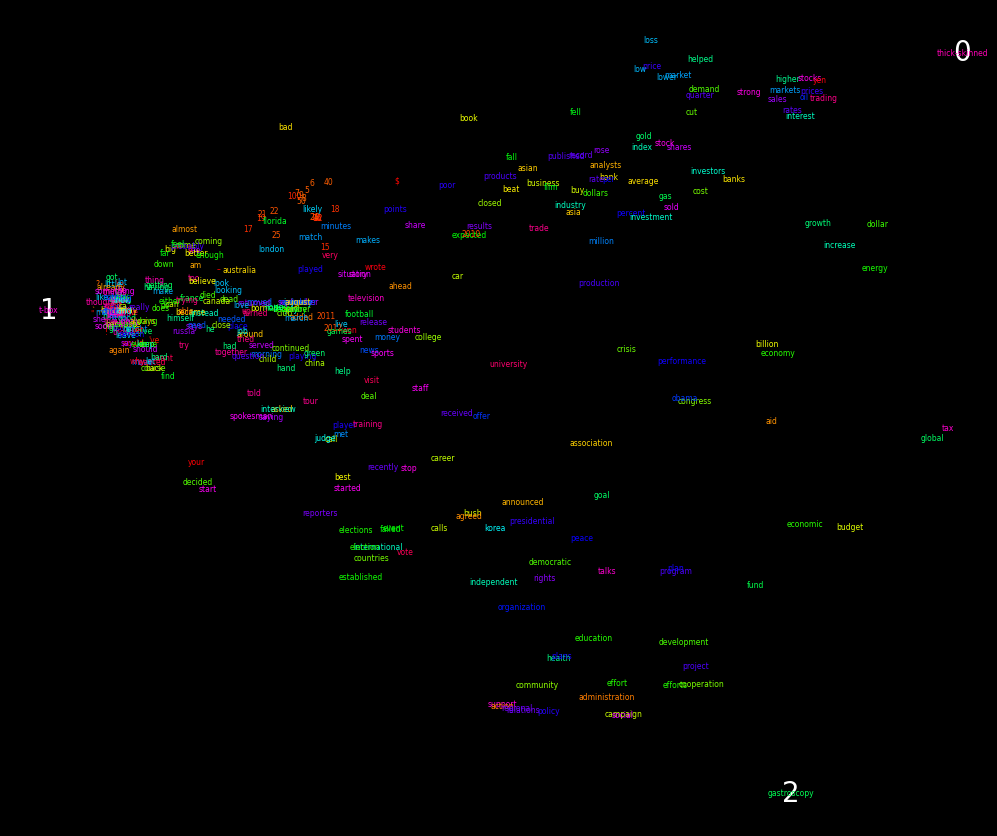

In [69]:
focus_on = np.array([0,1,2])
mnistVisuals.plot_points_from_file(config.params['file_path'], 1000, points, centroids, voltages, label_counts, 
                                            focus_on=focus_on, element='label', size_threshold=0, ratio_threshold=0)